# Revolut FAQ RAG Chatbot

A minimal single-turn RAG chatbot over Revolut help articles.

**Stack:** `openai` for embeddings + chat, `numpy` for similarity search, `json` for loading. No frameworks, no vector DB — everything in memory.

In [1]:
import asyncio
import json
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from dotenv import load_dotenv
from openai import AsyncOpenAI, OpenAI
from tqdm.auto import tqdm

load_dotenv()

PROJECT_ROOT = Path.cwd()
HW1_DIR = PROJECT_ROOT if (PROJECT_ROOT / "data" / "revolut_help_articles.jsonl").exists() else PROJECT_ROOT / "hw1"
if str(HW1_DIR.parent) not in sys.path:
    sys.path.insert(0, str(HW1_DIR.parent))
DATA_DIR = HW1_DIR / "data"

BASE_URL = "https://openrouter.ai/api/v1"
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"), base_url=BASE_URL)
async_client = AsyncOpenAI(api_key=os.getenv("OPENAI_API_KEY"), base_url=BASE_URL)

EMBED_MODEL = "openai/text-embedding-3-small"
CHAT_MODEL = "openai/gpt-3.5-turbo-instruct"  # feel free to replace with another WEAK model (use weak models to make it easier to find errors)
TOP_K = 4


## 1. Load articles

In [2]:
ARTICLES_PATH = DATA_DIR / "revolut_help_articles.jsonl"

articles = []
with open(ARTICLES_PATH, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        articles.append(json.loads(line))

print(f"Loaded {len(articles)} articles")
print("Example:", articles[0]["title"])


Loaded 786 articles
Example: How can I see my cashflow analytics?


## 2. Embed all articles

We embed `title + content_text` so the title contributes to retrieval. Batched to keep things fast.

In [3]:
def article_to_text(a):
    return f"{a['title']}\n\n{a['content_text']}"

def embed_texts(texts, batch_size=100):
    out = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]
        resp = client.embeddings.create(model=EMBED_MODEL, input=batch)
        out.extend([d.embedding for d in resp.data])
    return np.array(out, dtype=np.float32)

texts = [article_to_text(a) for a in articles]
embeddings = embed_texts(texts)

# L2-normalize once so cosine similarity is just a dot product
embeddings = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)

print("Embeddings shape:", embeddings.shape)

Embeddings shape: (786, 1536)


## 3. Retrieval

In [4]:
def retrieve(query, k=TOP_K):
    q_emb = client.embeddings.create(model=EMBED_MODEL, input=[query]).data[0].embedding
    q_vec = np.array(q_emb, dtype=np.float32)
    q_vec = q_vec / np.linalg.norm(q_vec)

    scores = embeddings @ q_vec
    top_idx = np.argsort(-scores)[:k]
    return [(int(i), float(scores[i]), articles[i]) for i in top_idx]


async def async_retrieve(query, k=TOP_K):
    resp = await async_client.embeddings.create(model=EMBED_MODEL, input=[query])
    q_vec = np.array(resp.data[0].embedding, dtype=np.float32)
    q_vec = q_vec / np.linalg.norm(q_vec)

    scores = embeddings @ q_vec
    top_idx = np.argsort(-scores)[:k]
    return [(int(i), float(scores[i]), articles[i]) for i in top_idx]


## 4. Single-turn chat

In [5]:
SYSTEM_PROMPT = (
    "You are a Revolut customer support assistant. "
    "Answer the user's question using ONLY the provided help articles. "
    "If the answer is not in the articles, say you don't know. "
    "Be concise and reference steps from the articles when relevant."
)

def format_context(hits):
    parts = []
    for rank, (idx, score, art) in enumerate(hits, start=1):
        parts.append(
            f"[Article {rank}] {art['title']}\n{art['content_text']}"
        )
    return "\n\n---\n\n".join(parts)

def build_user_message(question, context):
    return (
        f"Help articles:\n\n{context}\n\n"
        f"Question: {question}"
    )

def answer_with_context(question, k=TOP_K):
    hits = retrieve(question, k=k)
    context = format_context(hits)

    resp = client.chat.completions.create(
        model=CHAT_MODEL,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": build_user_message(question, context)},
        ],
        temperature=0.2,
    )
    answer = resp.choices[0].message.content
    return answer, context, hits

async def async_answer_with_context(question, k=TOP_K):
    hits = await async_retrieve(question, k=k)
    context = format_context(hits)

    resp = await async_client.chat.completions.create(
        model=CHAT_MODEL,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": build_user_message(question, context)},
        ],
        temperature=0.2,
    )
    answer = resp.choices[0].message.content
    return answer, context, hits

def ask(question, k=TOP_K):
    answer, _, hits = answer_with_context(question, k=k)
    return answer, hits


## 5. Try it

In [6]:
question = "Hi, Ive had a source of funds request after a few large transfers and Im a bit worried my account will be closed 😅 What docs do you actually need from me - salary slips, tax returns, bank statements, sale contracts, whatever - and how do I know whats enough to match the payments youre reviewing?"

answer, hits = ask(question)

print("Q:", question)
print("\nA:", answer)
print("\nRetrieved articles:")
for rank, (idx, score, art) in enumerate(hits, start=1):
    print(f"  {rank}. [{score:.3f}] {art['title']}")

Q: Hi, Ive had a source of funds request after a few large transfers and Im a bit worried my account will be closed 😅 What docs do you actually need from me - salary slips, tax returns, bank statements, sale contracts, whatever - and how do I know whats enough to match the payments youre reviewing?

A: Hello! Thank you for reaching out. We understand your concern and we want to assure you that we are just following our regulatory requirements to ensure the safety of your account and maintain compliance. We may need additional information about your source of funds, depending on the type of income you have. You can check which documents are accepted for your particular case in this FAQ/help/profile-and-plan/profile-plan/verifying-identity/documents-for-the-source-of-funds-verification. Please make sure to provide accurate and up-to-date information about your income and wealth. You can submit the documents through the app by following the instructions you see in-app. Make sure to upload

## 6. Evaluate Synthetic Dataset

Run every generated query through the RAG assistant and save both the answer and the retrieved context.


In [7]:
DATASET_PATH = DATA_DIR / "synthetic_revolut_queries.csv"
RAG_OUTPUT_PATH = DATA_DIR / "synthetic_revolut_rag_outputs.csv"
SAVE_EVERY = 25
RAG_CONCURRENCY = 8
MAX_EVAL_ROWS = None  # Set to a small int for a test run.
ROW_KEY = ["persona", "script", "modifier", "query"]

synthetic_df = pd.read_csv(DATASET_PATH)
if MAX_EVAL_ROWS is not None:
    synthetic_df = synthetic_df.head(MAX_EVAL_ROWS)

print(f"Loaded {len(synthetic_df)} synthetic queries")
synthetic_df.head()


Loaded 1050 synthetic queries


,persona,script,modifier,query
0,uk_freelance_designer,identity_passport_upload,empty,"hi, my revoult account’s been limited and the ..."
1,uk_freelance_designer,identity_passport_upload,poor_internet_connection,"Hi, my Revolut account’s been limited for an i..."
2,uk_freelance_designer,identity_passport_upload,anxious_security_fear,"Hi, my account’s been temporarily limited afte..."
3,uk_freelance_designer,identity_passport_upload,confused_by_app_updates,"Hi, my account’s been limited for a security c..."
4,uk_freelance_designer,identity_passport_upload,angry_after_waiting,why has my revoult account been limited and my...


In [8]:
def save_rows(rows, path):
    pd.DataFrame(rows).to_csv(path, index=False)


def make_key(row, columns):
    return tuple(str(row[col]) for col in columns)


def has_values(row, columns):
    return all(pd.notna(row.get(col)) and str(row.get(col)).strip() for col in columns)


async def answer_dataset_row(index, row, semaphore):
    async with semaphore:
        answer, context, hits = await async_answer_with_context(row["query"])

    return index, {
        "persona": row["persona"],
        "script": row["script"],
        "modifier": row["modifier"],
        "query": row["query"],
        "answer": answer,
        "extracted_context": context,
        "retrieved_articles": " | ".join(art["title"] for _, _, art in hits),
    }


async def run_rag_dataset(df):
    records = df.to_dict("records")
    rows = [None] * len(records)
    existing_by_key = {}

    if RAG_OUTPUT_PATH.exists():
        existing_df = pd.read_csv(RAG_OUTPUT_PATH)
        complete_existing = existing_df[
            existing_df.apply(
                lambda row: has_values(row, ["answer", "extracted_context"]),
                axis=1,
            )
        ]
        existing_by_key = {
            make_key(row, ROW_KEY): row
            for row in complete_existing.to_dict("records")
        }

    missing = []
    for index, row in enumerate(records):
        existing = existing_by_key.get(make_key(row, ROW_KEY))
        if existing is None:
            missing.append((index, row))
        else:
            rows[index] = existing

    print(f"RAG resume: {len(records) - len(missing)} done, {len(missing)} missing")
    if not missing:
        save_rows(rows, RAG_OUTPUT_PATH)
        return pd.DataFrame(rows)

    semaphore = asyncio.Semaphore(RAG_CONCURRENCY)
    tasks = [
        asyncio.create_task(answer_dataset_row(index, row, semaphore))
        for index, row in missing
    ]

    for task in tqdm(asyncio.as_completed(tasks), total=len(tasks), desc="RAG answers"):
        index, result = await task
        rows[index] = result
        completed = [row for row in rows if row is not None]
        if len(completed) % SAVE_EVERY == 0:
            save_rows(completed, RAG_OUTPUT_PATH)

    save_rows(rows, RAG_OUTPUT_PATH)
    return pd.DataFrame(rows)


rag_df = await run_rag_dataset(synthetic_df)
rag_df.head()


RAG resume: 1050 done, 0 missing


,persona,script,modifier,query,answer,extracted_context,retrieved_articles
0,uk_freelance_designer,identity_passport_upload,empty,"hi, my revoult account’s been limited and the ...","Hi there, it seems like your account has been ...",[Article 1] Verify my identity\n## Where do I ...,Verify my identity | Trouble with my selfie ve...
1,uk_freelance_designer,identity_passport_upload,poor_internet_connection,"Hi, my Revolut account’s been limited for an i...",Hi there! I'm sorry to hear that you're having...,[Article 1] Verify my identity\n## Where do I ...,Verify my identity | I'm unable to verify my i...
2,uk_freelance_designer,identity_passport_upload,anxious_security_fear,"Hi, my account’s been temporarily limited afte...","Hi there, I'm sorry to hear that your account ...",[Article 1] I was asked for additional informa...,I was asked for additional information about m...
3,uk_freelance_designer,identity_passport_upload,confused_by_app_updates,"Hi, my account’s been limited for a security c...",Hi there! I'm sorry to hear that your account ...,[Article 1] I was asked for additional informa...,I was asked for additional information about m...
4,uk_freelance_designer,identity_passport_upload,angry_after_waiting,why has my revoult account been limited and my...,"Based on the articles provided, it seems like ...",[Article 1] I'm unable to verify my identity\n...,I'm unable to verify my identity | My account ...


## 7. LLM-as-a-Judge Evaluation

Evaluate each RAG answer with the judge metrics and save the final table.


In [9]:
from hw1.judges import (
    judge_is_helpful,
    judge_legally_correct,
    judge_no_false_info,
    judge_not_excessive,
    judge_relevancy,
)

EVAL_OUTPUT_PATH = DATA_DIR / "synthetic_revolut_eval_results.csv"
JUDGE_CONCURRENCY = 8


In [10]:
async def evaluate_row(index, row, semaphore):
    query = row["query"]
    answer = row["answer"]
    context = row["extracted_context"]

    async with semaphore:
        relevancy, relevancy_reasoning = await judge_relevancy(query, answer)
        not_excessive, not_excessive_reasoning = await judge_not_excessive(query, answer)
        is_helpful, is_helpful_reasoning = await judge_is_helpful(query, answer)
        legally_correct, legally_correct_reasoning = await judge_legally_correct(query, answer)
        no_false_info, no_false_info_reasoning = await judge_no_false_info(
            query,
            answer,
            context,
        )

    return index, {
        "persona": row["persona"],
        "script": row["script"],
        "modifier": row["modifier"],
        "query": query,
        "answer": answer,
        "extracted_context": context,
        "relevancy": relevancy,
        "relevancy_reasoning": relevancy_reasoning,
        "not_excessive": not_excessive,
        "not_excessive_reasoning": not_excessive_reasoning,
        "is_helpful": is_helpful,
        "is_helpful_reasoning": is_helpful_reasoning,
        "legally_correct": legally_correct,
        "legally_correct_reasoning": legally_correct_reasoning,
        "no_false_info": no_false_info,
        "no_false_info_reasoning": no_false_info_reasoning,
    }


async def evaluate_answers(df):
    records = df.to_dict("records")
    rows = [None] * len(records)
    eval_key = ROW_KEY + ["answer"]
    metric_columns = [
        "relevancy",
        "relevancy_reasoning",
        "not_excessive",
        "not_excessive_reasoning",
        "is_helpful",
        "is_helpful_reasoning",
        "legally_correct",
        "legally_correct_reasoning",
        "no_false_info",
        "no_false_info_reasoning",
    ]
    existing_by_key = {}

    if EVAL_OUTPUT_PATH.exists():
        existing_df = pd.read_csv(EVAL_OUTPUT_PATH)
        complete_existing = existing_df[
            existing_df.apply(lambda row: has_values(row, metric_columns), axis=1)
        ]
        existing_by_key = {
            make_key(row, eval_key): row
            for row in complete_existing.to_dict("records")
        }

    missing = []
    for index, row in enumerate(records):
        existing = existing_by_key.get(make_key(row, eval_key))
        if existing is None:
            missing.append((index, row))
        else:
            rows[index] = existing

    print(f"Judge resume: {len(records) - len(missing)} done, {len(missing)} missing")
    if not missing:
        save_rows(rows, EVAL_OUTPUT_PATH)
        return pd.DataFrame(rows)

    semaphore = asyncio.Semaphore(JUDGE_CONCURRENCY)
    tasks = [
        asyncio.create_task(evaluate_row(index, row, semaphore))
        for index, row in missing
    ]

    for task in tqdm(asyncio.as_completed(tasks), total=len(tasks), desc="Judging"):
        index, result = await task
        rows[index] = result
        pd.DataFrame([row for row in rows if row is not None]).to_csv(
            EVAL_OUTPUT_PATH,
            index=False,
        )

    save_rows(rows, EVAL_OUTPUT_PATH)
    return pd.DataFrame(rows)


eval_df = await evaluate_answers(rag_df)
eval_df.head()


Judge resume: 54 done, 996 missing


Judging:   0%|          | 0/996 [00:00<?, ?it/s]

,persona,script,modifier,query,answer,extracted_context,relevancy,relevancy_reasoning,not_excessive,not_excessive_reasoning,is_helpful,is_helpful_reasoning,legally_correct,legally_correct_reasoning,no_false_info,no_false_info_reasoning
0,uk_freelance_designer,identity_passport_upload,empty,"hi, my revoult account’s been limited and the ...","Hi there, it seems like your account has been ...",[Article 1] Verify my identity\n## Where do I ...,True,The answer addresses the user's core issue: ac...,True,The response stays broadly on topic and gives ...,False,The answer gives a general suggestion to check...,True,The answer provides neutral support guidance a...,True,The answer only restates that the account may ...
1,uk_freelance_designer,identity_passport_upload,poor_internet_connection,"Hi, my Revolut account’s been limited for an i...",Hi there! I'm sorry to hear that you're having...,[Article 1] Verify my identity\n## Where do I ...,True,The answer addresses the user's identity check...,False,"The answer is mostly on-topic and brief, but i...",True,The answer gives a concrete path: check in-app...,True,The answer provides neutral support instructio...,True,The answer only states that identity-check pro...
2,uk_freelance_designer,identity_passport_upload,anxious_security_fear,"Hi, my account’s been temporarily limited afte...","Hi there, I'm sorry to hear that your account ...",[Article 1] I was asked for additional informa...,True,The assistant directly addresses the user's is...,False,The answer is somewhat concise and directly ad...,True,"The answer gives a clear, concrete next step: ...",False,The answer gives neutral support instructions ...,False,The answer is mostly supported: it mentions th...
3,uk_freelance_designer,identity_passport_upload,confused_by_app_updates,"Hi, my account’s been limited for a security c...",Hi there! I'm sorry to hear that your account ...,[Article 1] I was asked for additional informa...,True,The answer directly addresses the user’s issue...,True,The answer is mostly relevant and gives step-b...,True,The answer gives a concrete path to the identi...,True,The answer gives neutral account-security inst...,False,The answer mostly restates the app steps and g...
4,uk_freelance_designer,identity_passport_upload,angry_after_waiting,why has my revoult account been limited and my...,"Based on the articles provided, it seems like ...",[Article 1] I'm unable to verify my identity\n...,True,The answer is relevant because it addresses th...,True,The reply is somewhat concise and stays on top...,False,The answer gives a general next step (follow i...,True,The answer contains no toxic language and no c...,False,The answer is mostly supported: the context sa...


## 8. Metric Correlations and Distributions

Use the completed evaluation table to inspect metric pass rates, metric correlations, and where failures concentrate across seed aliases.


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

EVAL_OUTPUT_PATH = DATA_DIR / "synthetic_revolut_eval_results.csv"
METRIC_COLS = [
    "relevancy",
    "not_excessive",
    "is_helpful",
    "legally_correct",
    "no_false_info",
]

analysis_df = pd.read_csv(EVAL_OUTPUT_PATH)
print(f"Loaded {len(analysis_df)} evaluated rows")
analysis_df[METRIC_COLS].head()


Loaded 1050 evaluated rows


,relevancy,not_excessive,is_helpful,legally_correct,no_false_info
0,True,True,False,True,True
1,True,False,True,True,True
2,True,False,True,False,False
3,True,True,True,True,False
4,True,True,False,True,False


In [12]:
def metric_to_int(series):
    if series.dtype == bool:
        return series.astype(int)
    return series.astype(str).str.lower().map({"true": 1, "false": 0})

plot_df = analysis_df.copy()
for metric in METRIC_COLS:
    plot_df[metric] = metric_to_int(plot_df[metric])

plot_df["overall_score"] = plot_df[METRIC_COLS].mean(axis=1)
metric_long = plot_df.melt(
    id_vars=["persona", "script", "modifier", "overall_score"],
    value_vars=METRIC_COLS,
    var_name="metric",
    value_name="passed",
)

pass_rates = plot_df[METRIC_COLS].mean().sort_values(ascending=False)
pass_rates.to_frame("pass_rate")


,pass_rate
legally_correct,0.938095
relevancy,0.879048
not_excessive,0.789524
no_false_info,0.610476
is_helpful,0.406667


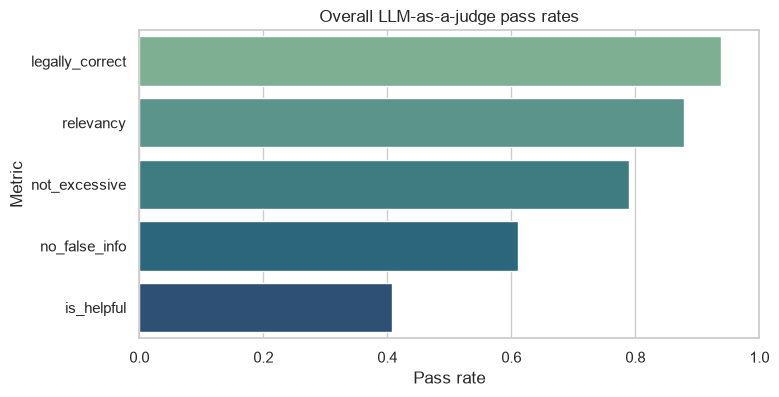

In [13]:
plt.figure(figsize=(8, 4))
sns.barplot(
    x=pass_rates.values,
    y=pass_rates.index,
    hue=pass_rates.index,
    palette="crest",
    legend=False,
)
plt.xlim(0, 1)
plt.xlabel("Pass rate")
plt.ylabel("Metric")
plt.title("Overall LLM-as-a-judge pass rates")
plt.show()


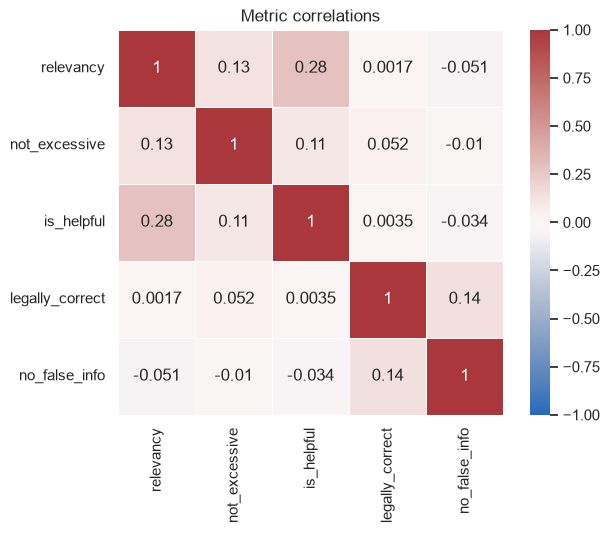

In [14]:
corr = plot_df[METRIC_COLS].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(
    corr,
    annot=True,
    vmin=-1,
    vmax=1,
    center=0,
    cmap="vlag",
    square=True,
    linewidths=0.5,
)
plt.title("Metric correlations")
plt.show()


### Metric Distribution by Seed Alias

Each cell is the share of answers that passed a metric for that seed alias.


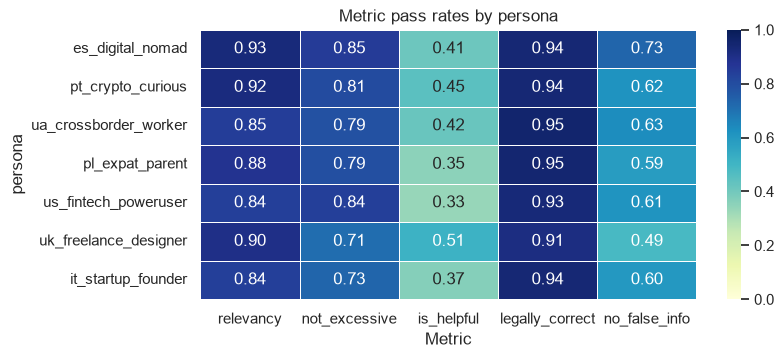

,relevancy,not_excessive,is_helpful,legally_correct,no_false_info,overall_score
persona,,,,,,
es_digital_nomad,0.926667,0.853333,0.413333,0.940000,0.733333,0.773333
pt_crypto_curious,0.920000,0.806667,0.446667,0.940000,0.620000,0.746667
ua_crossborder_worker,0.846667,0.786667,0.420000,0.953333,0.633333,0.728000
pl_expat_parent,0.880000,0.793333,0.353333,0.946667,0.586667,0.712000
us_fintech_poweruser,0.840000,0.840000,0.333333,0.933333,0.613333,0.712000
uk_freelance_designer,0.900000,0.713333,0.513333,0.913333,0.486667,0.705333
it_startup_founder,0.840000,0.733333,0.366667,0.940000,0.600000,0.696000


In [15]:
def plot_metric_heatmap(group_col, height_per_row=0.45, sort_by="overall_score"):
    grouped = plot_df.groupby(group_col)[METRIC_COLS + ["overall_score"]].mean()
    if sort_by in grouped.columns:
        grouped = grouped.sort_values(sort_by, ascending=False)
    metric_matrix = grouped[METRIC_COLS]

    plt.figure(figsize=(8, max(3, height_per_row * len(metric_matrix))))
    sns.heatmap(
        metric_matrix,
        annot=True,
        fmt=".2f",
        vmin=0,
        vmax=1,
        cmap="YlGnBu",
        linewidths=0.5,
    )
    plt.xlabel("Metric")
    plt.ylabel(group_col)
    plt.title(f"Metric pass rates by {group_col}")
    plt.show()

    return grouped

persona_summary = plot_metric_heatmap("persona", height_per_row=0.5)
persona_summary


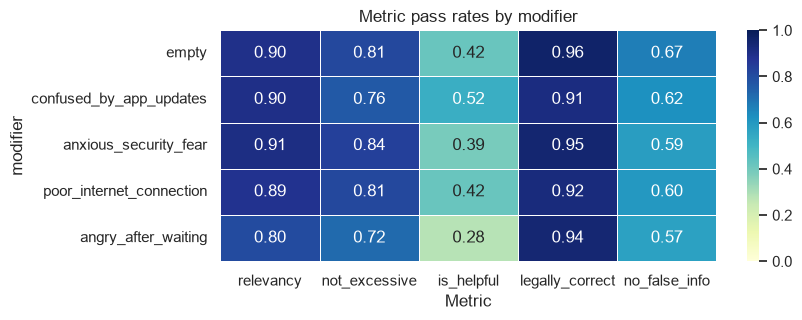

,relevancy,not_excessive,is_helpful,legally_correct,no_false_info,overall_score
modifier,,,,,,
empty,0.895238,0.814286,0.419048,0.961905,0.671429,0.752381
confused_by_app_updates,0.900000,0.761905,0.523810,0.914286,0.623810,0.744762
anxious_security_fear,0.909524,0.838095,0.390476,0.947619,0.585714,0.734286
poor_internet_connection,0.885714,0.814286,0.419048,0.923810,0.600000,0.728571
angry_after_waiting,0.804762,0.719048,0.280952,0.942857,0.571429,0.663810


In [16]:
modifier_summary = plot_metric_heatmap("modifier", height_per_row=0.6)
modifier_summary


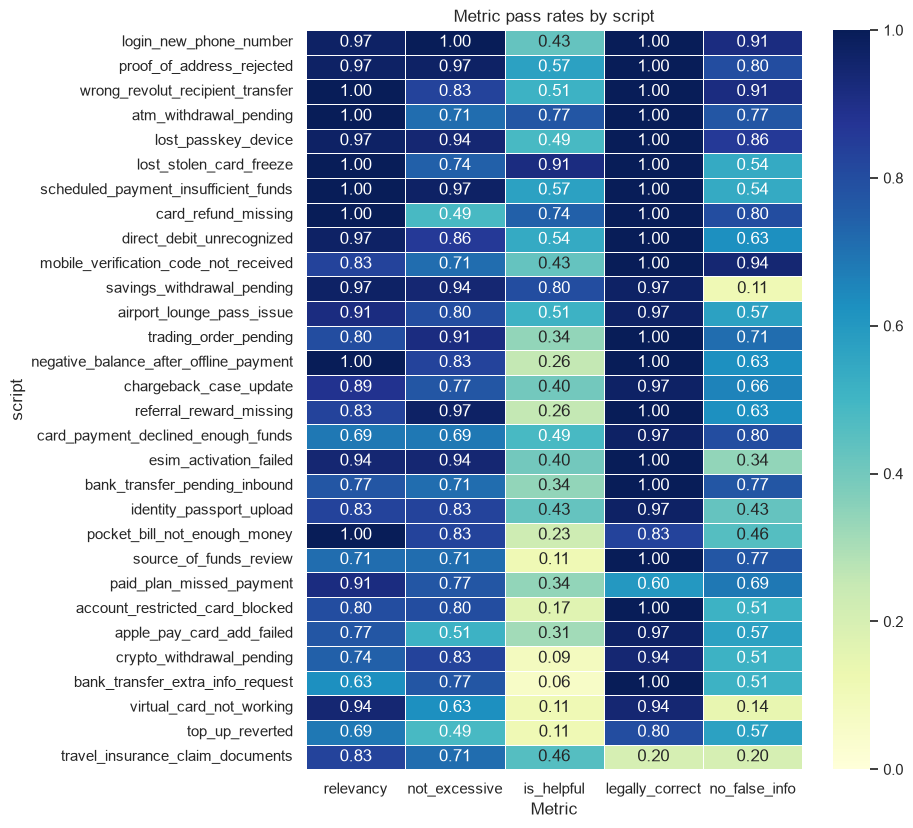

,relevancy,not_excessive,is_helpful,legally_correct,no_false_info,overall_score
script,,,,,,
login_new_phone_number,0.971429,1.000000,0.428571,1.0,0.914286,0.862857
proof_of_address_rejected,0.971429,0.971429,0.571429,1.0,0.800000,0.862857
wrong_revolut_recipient_transfer,1.000000,0.828571,0.514286,1.0,0.914286,0.851429
atm_withdrawal_pending,1.000000,0.714286,0.771429,1.0,0.771429,0.851429
lost_passkey_device,0.971429,0.942857,0.485714,1.0,0.857143,0.851429
lost_stolen_card_freeze,1.000000,0.742857,0.914286,1.0,0.542857,0.840000
scheduled_payment_insufficient_funds,1.000000,0.971429,0.571429,1.0,0.542857,0.817143
card_refund_missing,1.000000,0.485714,0.742857,1.0,0.800000,0.805714
direct_debit_unrecognized,0.971429,0.857143,0.542857,1.0,0.628571,0.800000


In [17]:
script_summary = plot_metric_heatmap("script", height_per_row=0.32)
script_summary.head(10)
